In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg
import matplotlib.patches as patches
import matplotlib as mpl
from mplsoccer import Pitch, VerticalPitch, FontManager, Sbopen, add_image
from matplotlib.font_manager import FontProperties
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as path_effects
from highlight_text import ax_text, fig_text
from PIL import Image
from mplsoccer import add_image
from urllib.request import urlopen
import os
from adjustText import adjust_text
from matplotlib.ticker import MaxNLocator

# Print the modified DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

green = '#69f900'
red = '#ff4b44'
blue = '#00a0de'
violet = '#a369ff'
bg_color= '#f5f5f5'
line_color= '#000000'
col1 = '#ff4b44'
col2 = '#00a0de'

In [3]:
font_path = r"C:\Fonts\Noto_Sans\static\NotoSans-Bold.ttf"
custom_font = FontProperties(fname=font_path)
font_path_thin = r"C:\Fonts\Noto_Sans\static\NotoSans-Regular.ttf"
custom_font_thin = FontProperties(fname=font_path_thin)

In [25]:
def bc_create(ax):
    df_bc_op = df[(df['type'].isin(['Goal', 'MissedShots', 'SavedShot', 'ShotOnPost'])) & (df['qualifiers'].str.contains('BigChance')) & (df['qualifiers'].str.contains('RegularPlay'))]
    df_bc_fb = df[(df['type'].isin(['Goal', 'MissedShots', 'SavedShot', 'ShotOnPost'])) & (df['qualifiers'].str.contains('BigChance')) & (df['qualifiers'].str.contains('FastBreak'))]
    df_bc_gl = df[(df['type']=='Goal') & (df['qualifiers'].str.contains('BigChance')) & (df['qualifiers'].str.contains('FastBreak|RegularPlay'))]
    op_counts = df_bc_op['teamName'].value_counts()
    fb_counts = df_bc_fb['teamName'].value_counts()
    gl_counts = df_bc_gl['teamName'].value_counts()

    # Create a dataframe with both series
    combined_df_alt = pd.DataFrame({
        'bc_regularplay_count': op_counts,
        'bc_fastbreak_count': fb_counts,
        'bc_goal_count': gl_counts
    }).fillna(0).astype(int)

    # Reset index to make teamName a column
    combined_df_alt = combined_df_alt.reset_index()
    combined_df_alt.columns = ['teamName', 'bc_regularplay_count', 'bc_fastbreak_count', 'bc_goal_count']

    combined_df_alt['bc_convr'] = round((combined_df_alt['bc_goal_count']/(combined_df_alt['bc_regularplay_count']+combined_df_alt['bc_fastbreak_count']))*100, 2)

    # Create a red-to-green colormap
    colors = ['#E90052', '#05F26C']
    cmap = LinearSegmentedColormap.from_list('red_green', colors, N=100)

    # Create the scatter plot with colors based on bc_convr values
    scatter = ax.scatter(combined_df_alt['bc_regularplay_count'], 
                        combined_df_alt['bc_fastbreak_count'], 
                        c=combined_df_alt['bc_convr'], 
                        cmap=cmap, 
                        # vmin=0, 
                        # vmax=100,
                        s=60,  # marker size
                        alpha=0.7)

    # Method 1: Using adjustText library (best solution)
    texts = []
    for index, row in combined_df_alt.iterrows():
        text = ax.annotate(row['teamName'], 
                        (row['bc_regularplay_count'], row['bc_fastbreak_count']), fontproperties=custom_font_thin,
                        fontsize=12, ha='left', va='bottom',
                        alpha=0.8)
        texts.append(text)

    # Automatically adjust text positions to avoid overlaps
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5))

    # Remove all spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # Calculate averages
    avg_x = combined_df_alt['bc_regularplay_count'].mean()
    avg_y = combined_df_alt['bc_fastbreak_count'].mean()

    # Add dashed lines at averages
    ax.axvline(x=avg_x, color='gray', linestyle='--', alpha=0.7, linewidth=1.5, label=f'Avg Regular Play: {avg_x:.1f}')
    ax.axhline(y=avg_y, color='gray', linestyle='--', alpha=0.7, linewidth=1.5, label=f'Avg Fast Break: {avg_y:.1f}')

    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("BC Conversion Rate (%)", rotation=270, labelpad=20, color='#404040')
    # Force integer ticks on colorbar
    cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    cbar.ax.tick_params(axis='both', which='major', labelsize=8, color='#404040', labelcolor='#404040')
    # If you need custom font, set it separately on the colorbar labels
    for label in cbar.ax.get_yticklabels():
        label.set_fontproperties(custom_font_thin)

    # Set labels and title
    ax.set_xlabel('BC Created from Regular Play', fontsize=15, fontweight='bold', fontproperties=custom_font)
    ax.set_ylabel('BC Created from Fast Break', fontsize=15, fontweight='bold', fontproperties=custom_font)
    # ax.set_title('How Teams Create Big Chances', fontsize=20, fontweight='bold', y=1.1)

    # Force integer ticks on both axes
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    # Change fontsize of axis tick labels
    ax.tick_params(axis='both', which='major', labelsize=10, color='#404040', labelcolor='#404040')
    # If you need custom font, set it separately on the labels
    for label in ax.get_yticklabels():
        label.set_fontproperties(custom_font_thin)
    for label in ax.get_xticklabels():
        label.set_fontproperties(custom_font_thin)

    # Add grid for better readability
    ax.grid(True, alpha=0.5, ls='dotted')

In [26]:
def bc_conc(ax):
    df_bc_op = df[(df['type'].isin(['Goal', 'MissedShots', 'SavedShot', 'ShotOnPost'])) & (df['qualifiers'].str.contains('BigChance')) & (df['qualifiers'].str.contains('RegularPlay'))]
    df_bc_fb = df[(df['type'].isin(['Goal', 'MissedShots', 'SavedShot', 'ShotOnPost'])) & (df['qualifiers'].str.contains('BigChance')) & (df['qualifiers'].str.contains('FastBreak'))]
    df_bc_gl = df[(df['type']=='Goal') & (df['qualifiers'].str.contains('BigChance')) & (df['qualifiers'].str.contains('FastBreak|RegularPlay'))]
    op_counts = df_bc_op['oppositionTeamName'].value_counts()
    fb_counts = df_bc_fb['oppositionTeamName'].value_counts()
    gl_counts = df_bc_gl['oppositionTeamName'].value_counts()

    # Create a dataframe with both series
    combined_df_alt = pd.DataFrame({
        'bc_regularplay_count': op_counts,
        'bc_fastbreak_count': fb_counts,
        'bc_goal_count': gl_counts
    }).fillna(0).astype(int)

    # Reset index to make teamName a column
    combined_df_alt = combined_df_alt.reset_index()
    combined_df_alt.columns = ['teamName', 'bc_regularplay_count', 'bc_fastbreak_count', 'bc_goal_count']

    combined_df_alt['bc_convr'] = round((combined_df_alt['bc_goal_count']/(combined_df_alt['bc_regularplay_count']+combined_df_alt['bc_fastbreak_count']))*100, 2)

    # Create a red-to-green colormap
    colors = ['#05F26C', '#E90052']
    cmap = LinearSegmentedColormap.from_list('red_green', colors, N=100)

    # Create the scatter plot with colors based on bc_convr values
    scatter = ax.scatter(combined_df_alt['bc_regularplay_count'], 
                        combined_df_alt['bc_fastbreak_count'], 
                        c=combined_df_alt['bc_convr'], 
                        cmap=cmap, 
                        # vmin=0, 
                        # vmax=100,
                        s=60,  # marker size
                        alpha=0.7)

    # Method 1: Using adjustText library (best solution)
    texts = []
    for index, row in combined_df_alt.iterrows():
        text = ax.annotate(row['teamName'], 
                        (row['bc_regularplay_count'], row['bc_fastbreak_count']), fontproperties=custom_font_thin,
                        fontsize=12, ha='left', va='bottom',
                        alpha=0.8)
        texts.append(text)

    # Automatically adjust text positions to avoid overlaps
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5))

    # Remove all spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # Calculate averages
    avg_x = combined_df_alt['bc_regularplay_count'].mean()
    avg_y = combined_df_alt['bc_fastbreak_count'].mean()

    # Add dashed lines at averages
    ax.axvline(x=avg_x, color='gray', linestyle='--', alpha=0.7, linewidth=1.5, label=f'Avg Regular Play: {avg_x:.1f}')
    ax.axhline(y=avg_y, color='gray', linestyle='--', alpha=0.7, linewidth=1.5, label=f'Avg Fast Break: {avg_y:.1f}')

    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("Opponent's BC Conversion Rate (%)", rotation=270, labelpad=20, color='#404040')
    # Force integer ticks on colorbar
    cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    cbar.ax.tick_params(axis='both', which='major', labelsize=8, color='#404040', labelcolor='#404040')
    # If you need custom font, set it separately on the colorbar labels
    for label in cbar.ax.get_yticklabels():
        label.set_fontproperties(custom_font_thin)

    # Set labels and title
    ax.set_xlabel('BC Conceded from Regular Play', fontsize=15, fontweight='bold', fontproperties=custom_font)
    ax.set_ylabel('BC Conceded from Fast Break', fontsize=15, fontweight='bold', fontproperties=custom_font)
    # ax.set_title('How Teams Create Big Chances', fontsize=20, fontweight='bold', y=1.1)

    # Force integer ticks on both axes
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    # Change fontsize of axis tick labels
    ax.tick_params(axis='both', which='major', labelsize=10, color='#404040', labelcolor='#404040')
    # If you need custom font, set it separately on the labels
    for label in ax.get_yticklabels():
        label.set_fontproperties(custom_font_thin)
    for label in ax.get_xticklabels():
        label.set_fontproperties(custom_font_thin)

    # Add grid for better readability
    ax.grid(True, alpha=0.5, ls='dotted')

    ax.invert_xaxis()
    ax.invert_yaxis()

In [35]:
league = 'Ligue_1'
season = '2024_25'
df = pd.read_csv(rf"D:\FData\All_Top_5_League\{season}\event_data\{league}_{season}_event_data.csv")

C:\Users\h\AppData\Local\Temp\ipykernel_22660\2715866756.py:3: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(rf"D:\FData\All_Top_5_League\{season}\event_data\{league}_{season}_event_data.csv")


Text(0.45, 0.92, 'Ligue 1 Teams in 2024-25 season | Data: Opta | made by: @adnaaan433')

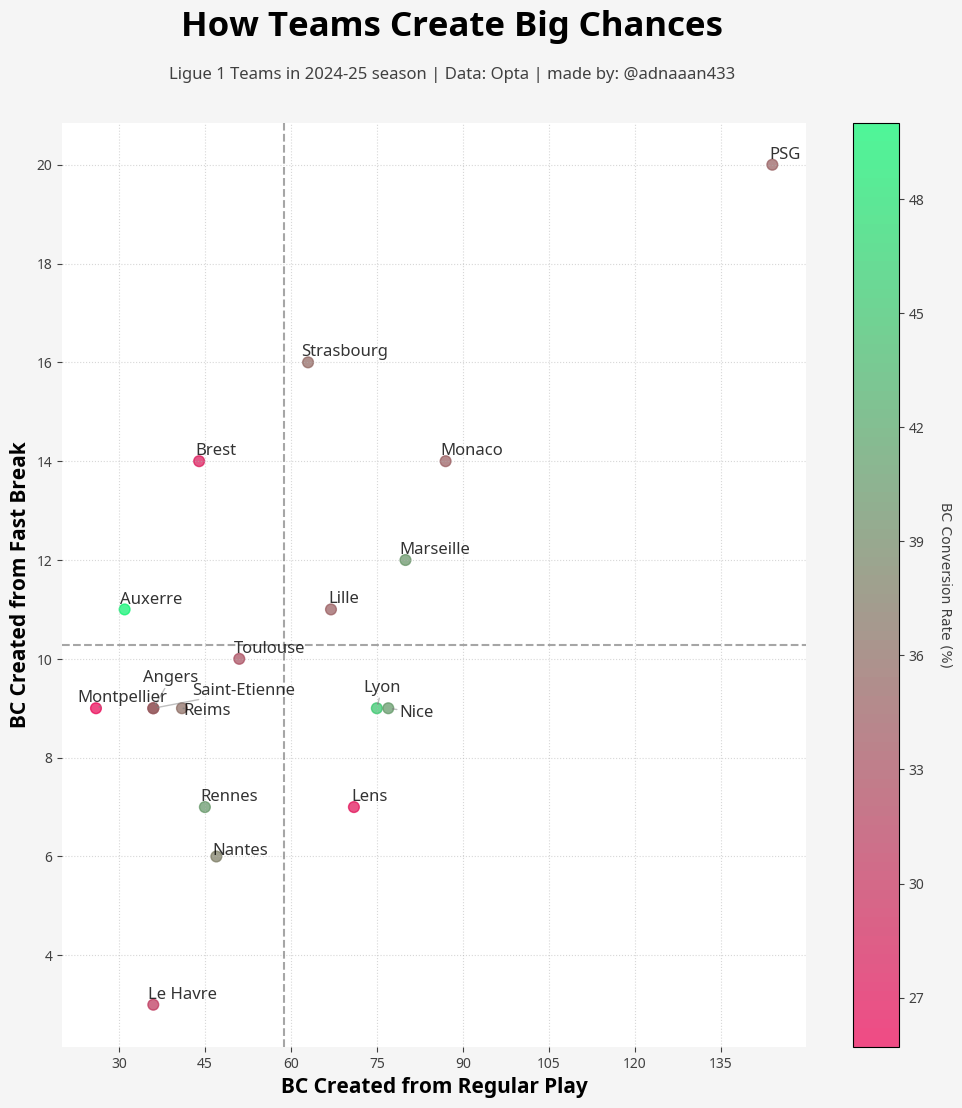

In [36]:
fig, ax = plt.subplots(figsize=(12, 12), facecolor='#f5f5f5')

bc_create(ax)
fig.text(0.45, 0.96, 'How Teams Create Big Chances', fontsize=25, fontweight='bold', ha='center', va='center', fontproperties=custom_font)
fig.text(0.45, 0.92, f"{league.replace('_', ' ')} Teams in {season.replace('_', '-')} season | Data: Opta | made by: @adnaaan433",
         fontsize=12, color='#404040', ha='center', va='center', fontproperties=custom_font_thin)

Text(0.45, 0.92, 'Ligue 1 Teams in 2024-25 season | Data: Opta | made by: @adnaaan433')

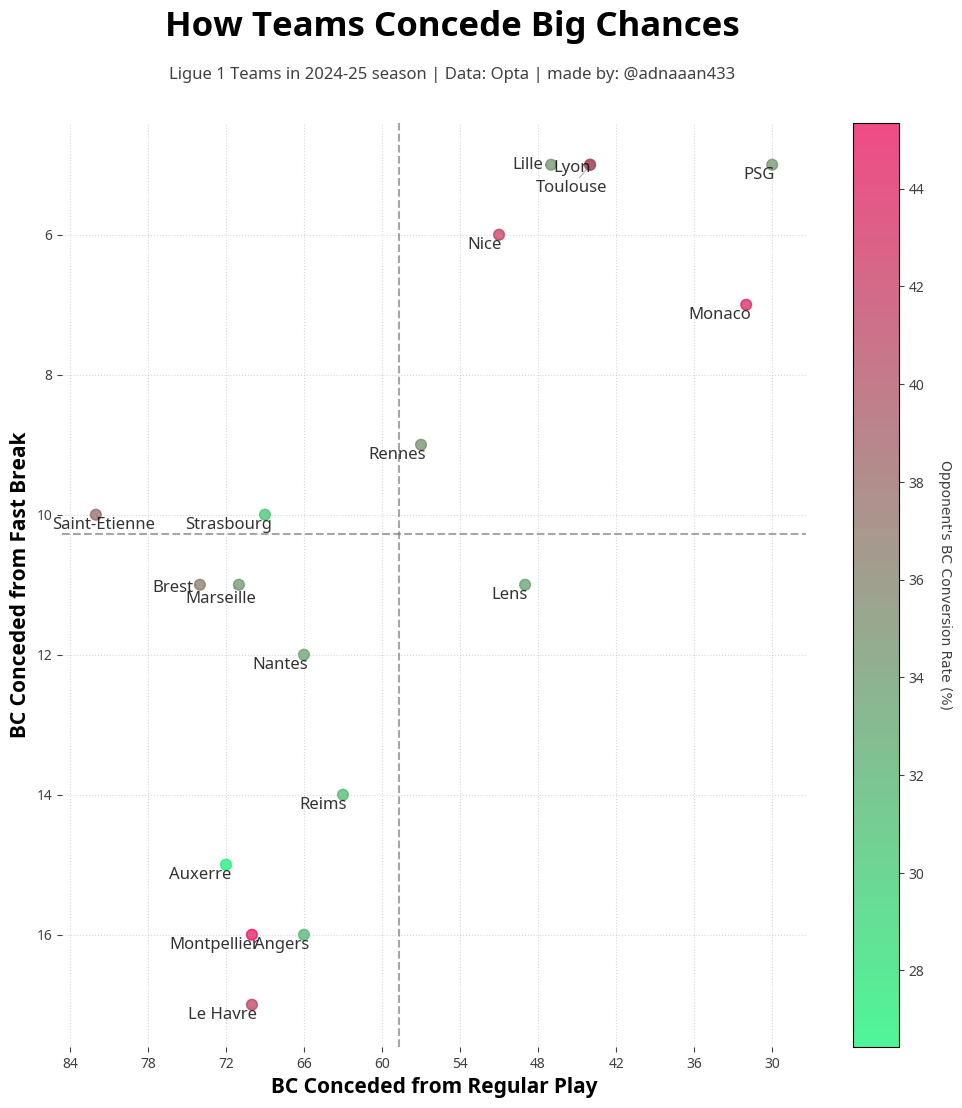

In [37]:
fig, ax = plt.subplots(figsize=(12, 12))

bc_conc(ax)
fig.text(0.45, 0.96, 'How Teams Concede Big Chances', fontsize=25, fontweight='bold', ha='center', va='center', fontproperties=custom_font)
fig.text(0.45, 0.92, f"{league.replace('_', ' ')} Teams in {season.replace('_', '-')} season | Data: Opta | made by: @adnaaan433",
         fontsize=12, color='#404040', ha='center', va='center', fontproperties=custom_font_thin)